# COMP 262 Final Project - Group 5

## Sentiment Analysis and Review-Enhanced Recommendation for Amazon Gift Cards Reviews

This notebook implements both phases of the COMP 262 project using the assigned **Group 5: Amazon Gift Cards** dataset.

Data source: [Amazon Review Data 2018 - Jianmo Ni / UCSD](https://nijianmo.github.io/amazon/index.html)

Main tasks covered:

- Phase 1 EDA, cleaning, 1,000-review sample, VADER and SentiWordNet lexicon sentiment classifiers.
- Phase 2 larger-subset EDA, TF-IDF representation, Logistic Regression and Naive Bayes sentiment classifiers.
- Apples-to-apples lexicon vs ML comparison on the same Phase 2 test set.
- Review-sentiment weighted rating enhancement for a simple recommender experiment.
- Local Hugging Face LLM tasks: 10 review summaries and one customer-service response.

## 0. Reproducible Setup

The notebook is written to run from the `Final Project` folder. If the raw data files are missing, it downloads them into `data/raw/`.

In [1]:
from pathlib import Path
import gzip
import json
import math
import os
import re
import ssl
import time
import urllib.request
import warnings
from collections import Counter
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

import nltk
from nltk.corpus import sentiwordnet as swn
from nltk.corpus import stopwords
from nltk.corpus import wordnet as wn
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import TreebankWordTokenizer

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
PHASE1_SAMPLE_N = 1000
PHASE2_MODEL_SAMPLE_N = 20000  # larger than the 2,000-review minimum while keeping runtime manageable
LABEL_ORDER = ['negative', 'neutral', 'positive']

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != 'Final Project' and (PROJECT_DIR / 'NLP work' / 'Final Project').exists():
    PROJECT_DIR = PROJECT_DIR / 'NLP work' / 'Final Project'
PROJECT_DIR = PROJECT_DIR.resolve()
RAW_DIR = PROJECT_DIR / 'data' / 'raw'
RAW_DIR.mkdir(parents=True, exist_ok=True)

PHASE1_PATH = RAW_DIR / 'Gift_Cards_5.json.gz'
PHASE2_PATH = RAW_DIR / 'Gift_Cards.json.gz'

PHASE1_URL = 'https://jmcauley.ucsd.edu/data/amazon_v2/categoryFilesSmall/Gift_Cards_5.json.gz'
PHASE2_URL = 'https://jmcauley.ucsd.edu/data/amazon_v2/categoryFiles/Gift_Cards.json.gz'

print('Project directory:', PROJECT_DIR)
print('Raw data directory:', RAW_DIR)

Project directory: /Users/zizo/Documents/Centennial/School/3402/Sem6/262 - NLP and Rec Sys/NLP work/Final Project
Raw data directory: /Users/zizo/Documents/Centennial/School/3402/Sem6/262 - NLP and Rec Sys/NLP work/Final Project/data/raw


In [2]:
def download_if_missing(url: str, path: Path) -> None:
    """Download a dataset file if it does not exist locally."""
    if path.exists() and path.stat().st_size > 0:
        print(f'Found {path.name}: {path.stat().st_size / 1024 / 1024:.2f} MB')
        return
    print(f'Downloading {path.name}...')
    context = ssl._create_unverified_context()
    with urllib.request.urlopen(url, context=context) as response, open(path, 'wb') as out:
        out.write(response.read())
    print(f'Downloaded {path.name}: {path.stat().st_size / 1024 / 1024:.2f} MB')

for url, path in [(PHASE1_URL, PHASE1_PATH), (PHASE2_URL, PHASE2_PATH)]:
    download_if_missing(url, path)

Found Gift_Cards_5.json.gz: 0.17 MB
Found Gift_Cards.json.gz: 10.81 MB


In [3]:
def ensure_nltk_resource(resource_name: str, resource_path: str) -> None:
    try:
        nltk.data.find(resource_path)
    except LookupError:
        print(f'Downloading NLTK resource: {resource_name}')
        nltk.download(resource_name, quiet=True)

required_nltk = [
    ('vader_lexicon', 'sentiment/vader_lexicon.zip'),
    ('sentiwordnet', 'corpora/sentiwordnet.zip'),
    ('wordnet', 'corpora/wordnet.zip'),
    ('omw-1.4', 'corpora/omw-1.4.zip'),
    ('stopwords', 'corpora/stopwords.zip'),
]
for name, path in required_nltk:
    ensure_nltk_resource(name, path)

# NLTK changed POS tagger resource names in newer versions; try both safely.
try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng', quiet=True)
try:
    nltk.data.find('taggers/averaged_perceptron_tagger')
except LookupError:
    nltk.download('averaged_perceptron_tagger', quiet=True)

print('NLTK resources ready.')

NLTK resources ready.


## 1. Loading, Schema Checks, and Labeling

The key dataset fields used are:

- `reviewerID`: reviewer/user identifier.
- `asin`: product identifier.
- `overall`: star rating, used to create the target sentiment label.
- `reviewText`: primary text used for sentiment analysis.
- `summary`: fallback text only when `reviewText` is missing or empty.
- `vote`: helpfulness votes when available.
- `reviewTime` / `unixReviewTime`: review date fields for time-based EDA.

Label rule required by the assignment:

- Ratings 4-5 = `positive`
- Rating 3 = `neutral`
- Ratings 1-2 = `negative`

In [4]:
EXPECTED_COLUMNS = ['reviewerID', 'asin', 'overall', 'reviewText', 'summary', 'vote', 'reviewTime', 'unixReviewTime']

def parse_json_gz(path: Path) -> pd.DataFrame:
    rows = []
    with gzip.open(path, 'rt', encoding='utf-8') as handle:
        for line_no, line in enumerate(handle, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError as exc:
                raise ValueError(f'Invalid JSON at {path.name}:{line_no}') from exc
    df = pd.DataFrame(rows)
    for col in EXPECTED_COLUMNS:
        if col not in df.columns:
            df[col] = np.nan
    return df


def rating_to_label(value):
    if pd.isna(value):
        return np.nan
    value = float(value)
    if value >= 4:
        return 'positive'
    if value == 3:
        return 'neutral'
    return 'negative'


def normalize_vote(value):
    if pd.isna(value):
        return 0
    if isinstance(value, str):
        value = value.replace(',', '').strip()
    try:
        return int(value)
    except (TypeError, ValueError):
        return 0


def add_clean_columns(df: pd.DataFrame, source_name: str) -> pd.DataFrame:
    out = df.copy()
    out['source'] = source_name
    out['overall'] = pd.to_numeric(out['overall'], errors='coerce')
    out['vote_count'] = out['vote'].apply(normalize_vote)
    out['reviewText'] = out['reviewText'].fillna('').astype(str)
    out['summary'] = out['summary'].fillna('').astype(str)
    out['review_text_clean'] = out['reviewText'].str.strip()
    out['summary_clean'] = out['summary'].str.strip()
    out['text'] = out['review_text_clean']
    empty_text = out['text'].str.len() == 0
    out.loc[empty_text, 'text'] = out.loc[empty_text, 'summary_clean']
    out['label'] = out['overall'].apply(rating_to_label)
    out['review_datetime'] = pd.to_datetime(out['unixReviewTime'], unit='s', errors='coerce')
    out['word_count'] = out['text'].str.findall(r'\b\w+\b').str.len()
    out['char_count'] = out['text'].str.len()
    out['has_question'] = out['text'].str.contains(r'\?', regex=True, na=False)
    return out


def clean_reviews(df: pd.DataFrame, source_name: str) -> pd.DataFrame:
    out = add_clean_columns(df, source_name)
    before = len(out)
    out = out.dropna(subset=['reviewerID', 'asin', 'overall', 'label']).copy()
    out = out[out['text'].str.len() > 0].copy()
    out = out.drop_duplicates(subset=['reviewerID', 'asin', 'overall', 'text']).copy()
    out = out.reset_index(drop=True)
    print(f'{source_name}: {before:,} raw rows -> {len(out):,} cleaned rows')
    return out

phase1_raw = parse_json_gz(PHASE1_PATH)
phase2_raw = parse_json_gz(PHASE2_PATH)
phase1 = clean_reviews(phase1_raw, 'Gift Cards 5-core')
phase2_full = clean_reviews(phase2_raw, 'Gift Cards full')

schema_summary = pd.DataFrame({
    'dataset': ['Phase 1 5-core', 'Phase 2 full'],
    'raw_rows': [len(phase1_raw), len(phase2_raw)],
    'clean_rows': [len(phase1), len(phase2_full)],
    'unique_users': [phase1['reviewerID'].nunique(), phase2_full['reviewerID'].nunique()],
    'unique_products': [phase1['asin'].nunique(), phase2_full['asin'].nunique()],
    'missing_reviewText_raw': [phase1_raw['reviewText'].isna().sum() + (phase1_raw['reviewText'].fillna('').astype(str).str.strip() == '').sum(),
                               phase2_raw['reviewText'].isna().sum() + (phase2_raw['reviewText'].fillna('').astype(str).str.strip() == '').sum()],
    'duplicate_clean_key_rows': [phase1.duplicated(['reviewerID', 'asin', 'overall', 'text']).sum(),
                                 phase2_full.duplicated(['reviewerID', 'asin', 'overall', 'text']).sum()],
})
display(schema_summary)

Gift Cards 5-core: 2,972 raw rows -> 2,971 cleaned rows


Gift Cards full: 147,194 raw rows -> 147,165 cleaned rows


,dataset,raw_rows,clean_rows,unique_users,unique_products,missing_reviewText_raw,duplicate_clean_key_rows
0,Phase 1 5-core,2972,2971,458,148,12,0
1,Phase 2 full,147194,147165,128870,1548,318,0


## 2. EDA Utilities

Outliers are reported rather than deleted by default. Very long reviews can be meaningful for sentiment and LLM tasks, so the notebook flags them with an IQR rule but preserves them unless they are empty duplicates.

,dataset,reviews,unique_products,unique_users,avg_rating,median_rating,avg_words_per_review,median_words_per_review,max_words,review_length_outliers_iqr,avg_reviews_per_product,max_reviews_per_product,avg_reviews_per_user,max_reviews_per_user,date_min,date_max
0,Phase 1 - Gift Cards 5-core,2971,148,458,4.885224,5.0,12.998990,5.0,454,257,20.074324,94,6.486900,32,2012-01-31,2018-08-22
1,Phase 2 - Gift Cards full,147165,1548,128870,4.671940,5.0,18.728251,11.0,910,8537,95.067829,8169,1.141965,39,2008-12-06,2018-09-30


,,phase1_count,phase2_count
overall,label,,
1.0,negative,22,7164
2.0,negative,11,1644
3.0,neutral,33,2996
4.0,positive,154,8699
5.0,positive,2751,126662


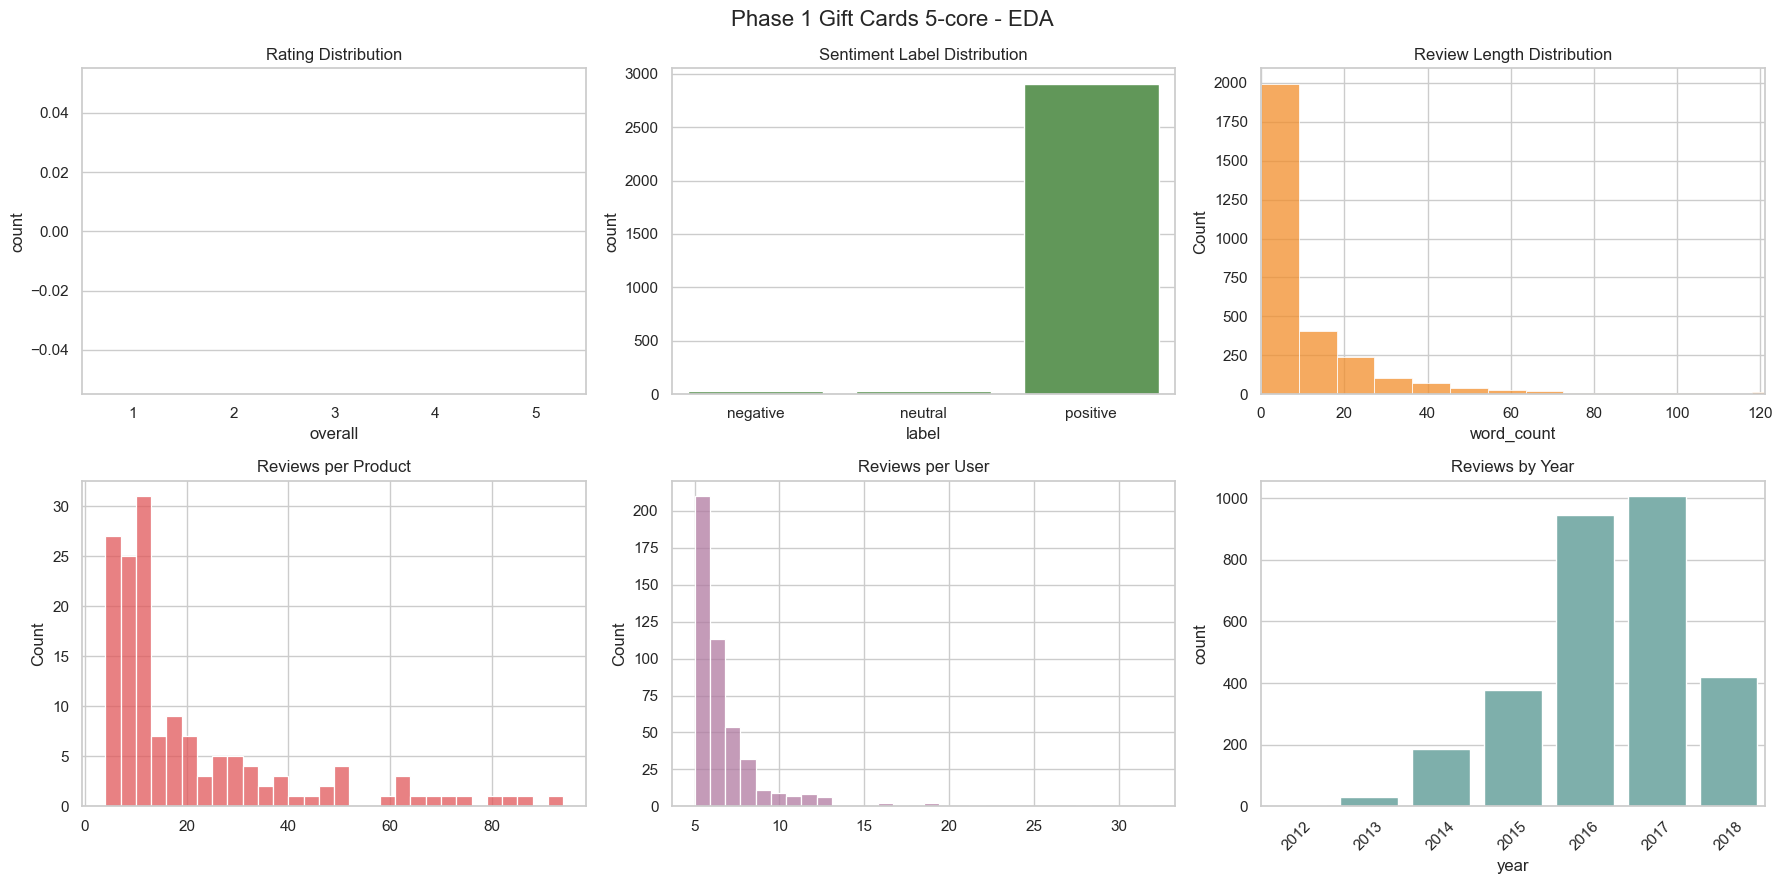

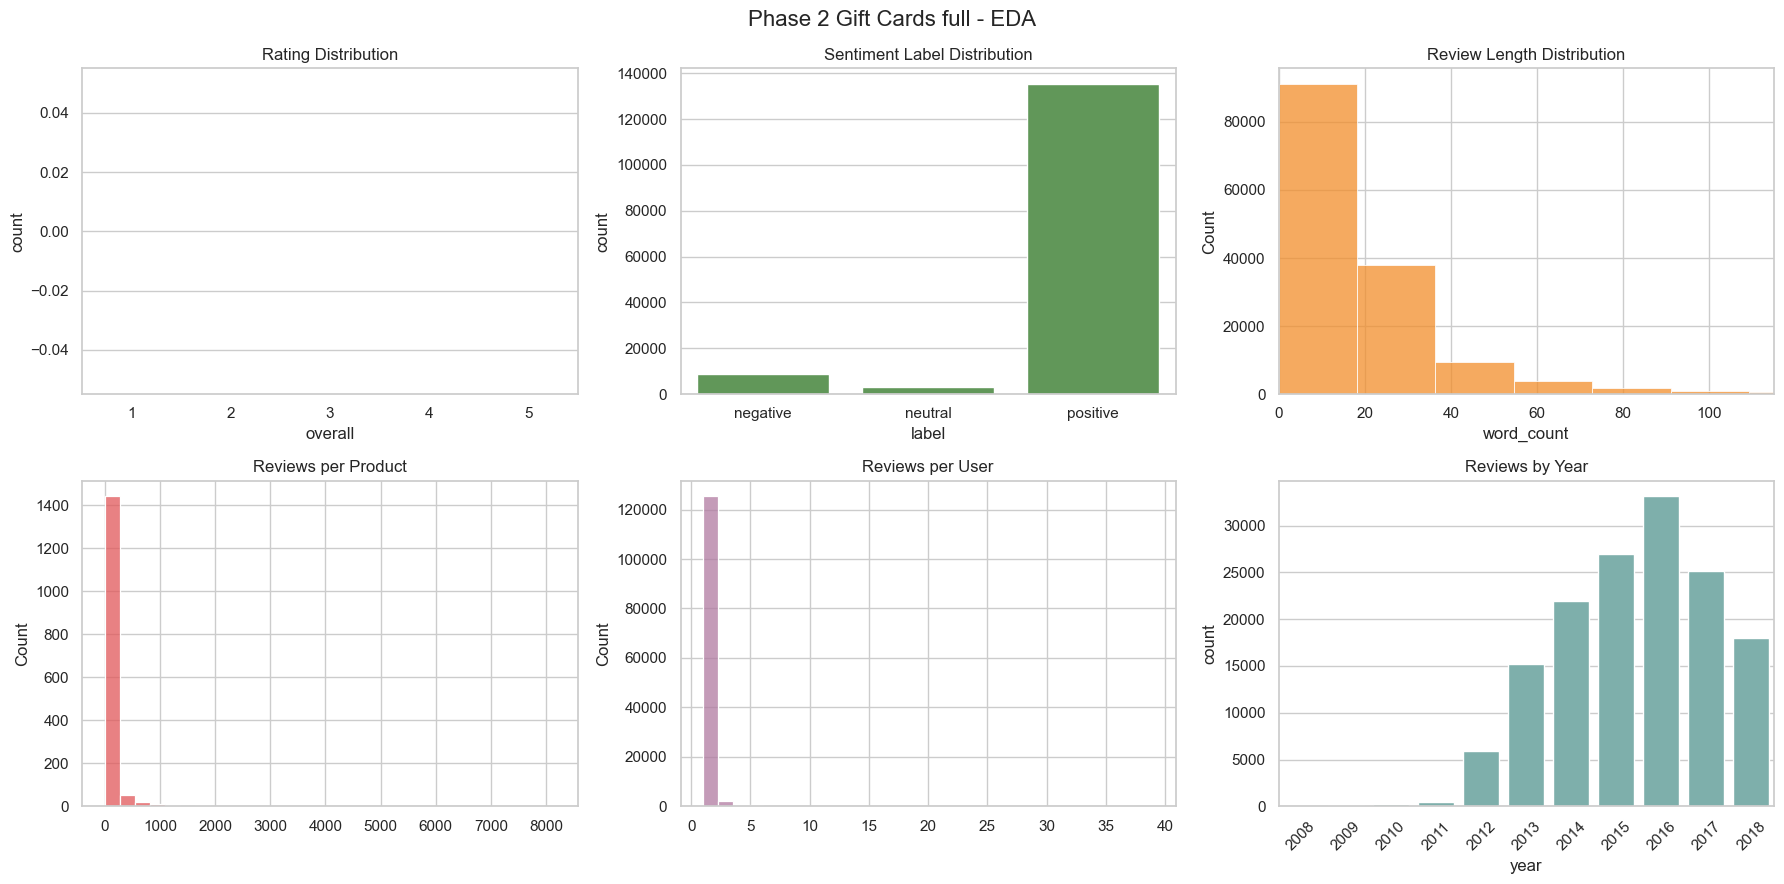

In [5]:
def dataset_overview(df: pd.DataFrame, name: str) -> pd.DataFrame:
    product_counts = df.groupby('asin').size()
    user_counts = df.groupby('reviewerID').size()
    q1, q3 = df['word_count'].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    rows = {
        'dataset': name,
        'reviews': len(df),
        'unique_products': df['asin'].nunique(),
        'unique_users': df['reviewerID'].nunique(),
        'avg_rating': df['overall'].mean(),
        'median_rating': df['overall'].median(),
        'avg_words_per_review': df['word_count'].mean(),
        'median_words_per_review': df['word_count'].median(),
        'max_words': df['word_count'].max(),
        'review_length_outliers_iqr': int((df['word_count'] > upper).sum()),
        'avg_reviews_per_product': product_counts.mean(),
        'max_reviews_per_product': product_counts.max(),
        'avg_reviews_per_user': user_counts.mean(),
        'max_reviews_per_user': user_counts.max(),
        'date_min': df['review_datetime'].min(),
        'date_max': df['review_datetime'].max(),
    }
    return pd.DataFrame([rows])


def plot_eda(df: pd.DataFrame, name: str) -> None:
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    fig.suptitle(f'{name} - EDA', fontsize=16)

    sns.countplot(data=df, x='overall', order=[1, 2, 3, 4, 5], ax=axes[0, 0], color='#4C78A8')
    axes[0, 0].set_title('Rating Distribution')

    sns.countplot(data=df, x='label', order=LABEL_ORDER, ax=axes[0, 1], color='#59A14F')
    axes[0, 1].set_title('Sentiment Label Distribution')

    sns.histplot(df['word_count'], bins=50, ax=axes[0, 2], color='#F28E2B')
    axes[0, 2].set_title('Review Length Distribution')
    axes[0, 2].set_xlim(0, min(df['word_count'].quantile(0.99), max(df['word_count'])))

    product_counts = df.groupby('asin').size()
    sns.histplot(product_counts, bins=30, ax=axes[1, 0], color='#E15759')
    axes[1, 0].set_title('Reviews per Product')

    user_counts = df.groupby('reviewerID').size()
    sns.histplot(user_counts, bins=30, ax=axes[1, 1], color='#B07AA1')
    axes[1, 1].set_title('Reviews per User')

    yearly = df.dropna(subset=['review_datetime']).assign(year=lambda x: x['review_datetime'].dt.year)
    sns.countplot(data=yearly, x='year', ax=axes[1, 2], color='#76B7B2')
    axes[1, 2].set_title('Reviews by Year')
    axes[1, 2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

phase1_overview = dataset_overview(phase1, 'Phase 1 - Gift Cards 5-core')
phase2_overview = dataset_overview(phase2_full, 'Phase 2 - Gift Cards full')
display(pd.concat([phase1_overview, phase2_overview], ignore_index=True))

rating_label_table = pd.concat([
    phase1.groupby(['overall', 'label']).size().rename('phase1_count'),
    phase2_full.groupby(['overall', 'label']).size().rename('phase2_count')
], axis=1).fillna(0).astype(int)
display(rating_label_table)

plot_eda(phase1, 'Phase 1 Gift Cards 5-core')
plot_eda(phase2_full, 'Phase 2 Gift Cards full')

## 3. Phase 1: 1,000-Review Random Sample

The assignment asks for a random sample of 1,000 reviews. A fixed seed is used so results can be reproduced.

Phase 1 sample rows: 1000


,count
label,
negative,15
neutral,5
positive,980


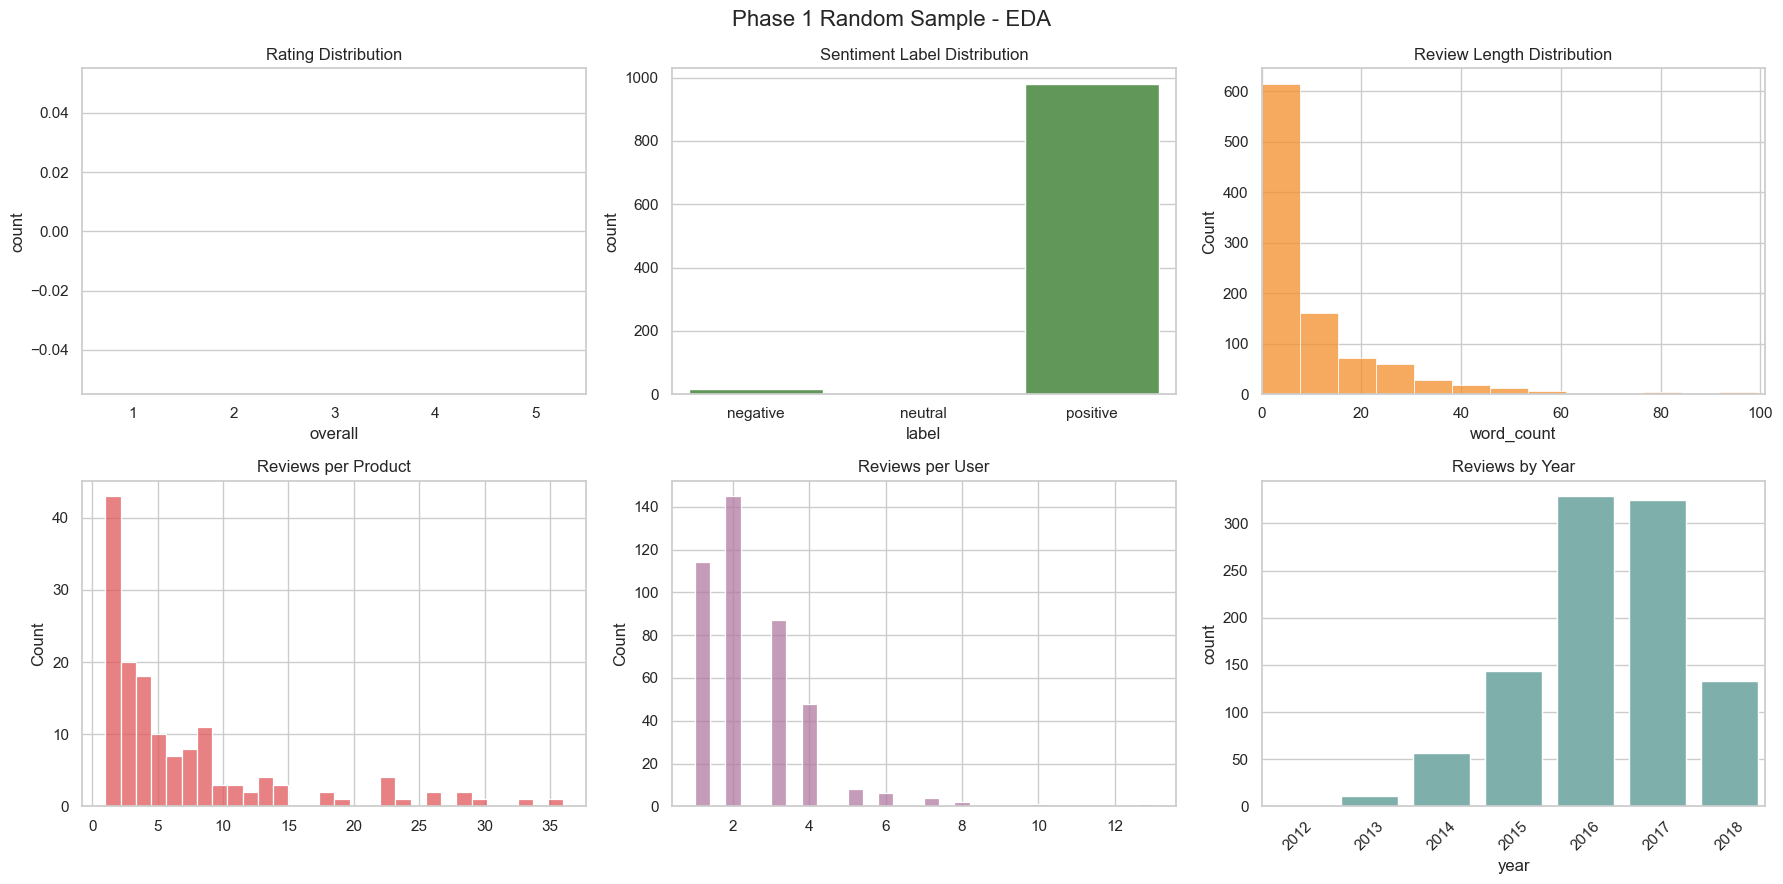

In [6]:
if len(phase1) < PHASE1_SAMPLE_N:
    raise ValueError(f'Phase 1 needs {PHASE1_SAMPLE_N} clean reviews but only found {len(phase1)}')

phase1_sample = phase1.sample(n=PHASE1_SAMPLE_N, random_state=RANDOM_STATE).reset_index(drop=True)
print('Phase 1 sample rows:', len(phase1_sample))
display(phase1_sample['label'].value_counts().reindex(LABEL_ORDER).fillna(0).astype(int).rename('count').to_frame())
plot_eda(phase1_sample, 'Phase 1 Random Sample')

## 4. Lexicon Sentiment Models: VADER and SentiWordNet

Preprocessing differs by lexicon:

- **VADER**: uses raw review text because punctuation, capitalization, negation, and intensity markers affect its compound score.
- **SentiWordNet**: uses tokenization, lowercasing, stopword/punctuation removal, POS tagging, and lemmatization because scores are attached to WordNet synsets.

In [7]:
vader_analyzer = SentimentIntensityAnalyzer()

def vader_score(text: str) -> float:
    return float(vader_analyzer.polarity_scores(str(text))['compound'])


def score_to_label(score: float, positive_threshold: float = 0.05, negative_threshold: float = -0.05) -> str:
    if score >= positive_threshold:
        return 'positive'
    if score <= negative_threshold:
        return 'negative'
    return 'neutral'

# SentiWordNet preprocessing objects
TOKENIZER = TreebankWordTokenizer()
LEMMATIZER = WordNetLemmatizer()
STOPWORDS = set(stopwords.words('english'))


def penn_to_wn(tag: str):
    if tag.startswith('J'):
        return wn.ADJ
    if tag.startswith('V'):
        return wn.VERB
    if tag.startswith('N'):
        return wn.NOUN
    if tag.startswith('R'):
        return wn.ADV
    return None


@lru_cache(maxsize=100000)
def cached_swn_token_score(lemma: str, wn_pos: str):
    synsets = list(swn.senti_synsets(lemma, wn_pos))
    if not synsets:
        return None
    first = synsets[0]
    return float(first.pos_score() - first.neg_score())


def sentiwordnet_score(text: str) -> float:
    tokens = [tok.lower() for tok in TOKENIZER.tokenize(str(text))]
    tokens = [tok for tok in tokens if tok.isalpha() and tok not in STOPWORDS]
    if not tokens:
        return 0.0
    tagged = nltk.pos_tag(tokens)
    scores = []
    for token, tag in tagged:
        wn_pos = penn_to_wn(tag)
        if wn_pos is None:
            continue
        lemma = LEMMATIZER.lemmatize(token, pos=wn_pos)
        score = cached_swn_token_score(lemma, wn_pos)
        if score is not None:
            scores.append(score)
    if not scores:
        return 0.0
    return float(np.mean(scores))


def sentiwordnet_label(score: float) -> str:
    # Narrow threshold because averaged synset sentiment scores are usually small.
    return score_to_label(score, positive_threshold=0.01, negative_threshold=-0.01)


def add_lexicon_predictions(df: pd.DataFrame, include_swn: bool = True) -> pd.DataFrame:
    out = df.copy()
    out['vader_score'] = out['text'].apply(vader_score)
    out['vader_pred'] = out['vader_score'].apply(score_to_label)
    if include_swn:
        start = time.time()
        out['swn_score'] = out['text'].apply(sentiwordnet_score)
        out['swn_pred'] = out['swn_score'].apply(sentiwordnet_label)
        print(f'SentiWordNet scored {len(out):,} reviews in {time.time() - start:.1f}s')
    return out

phase1_scored = add_lexicon_predictions(phase1_sample, include_swn=True)
display(phase1_scored[['overall', 'label', 'vader_score', 'vader_pred', 'swn_score', 'swn_pred', 'text']].head())

SentiWordNet scored 1,000 reviews in 2.9s


,overall,label,vader_score,vader_pred,swn_score,swn_pred,text
0,5.0,positive,0.8564,positive,0.031250,positive,Amazon gift cards are AMAZING!
1,5.0,positive,0.0000,neutral,0.062500,positive,Frankly I thought their prices were high so I ...
2,5.0,positive,0.8858,positive,0.150000,positive,A great gift for stress free holidays!
3,5.0,positive,0.2023,positive,0.187500,positive,worked fine
4,5.0,positive,0.6900,positive,0.041667,positive,This was a Christmas gift for my sister & brot...


,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,Phase 1 VADER,0.865,0.383925,0.403628,0.383482,0.967907,0.865,0.912993
1,Phase 1 SentiWordNet,0.698,0.354674,0.391270,0.315456,0.968547,0.698,0.809293


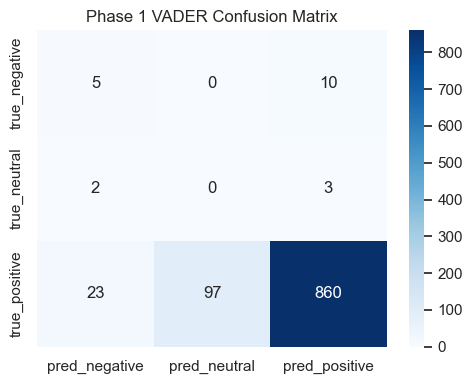

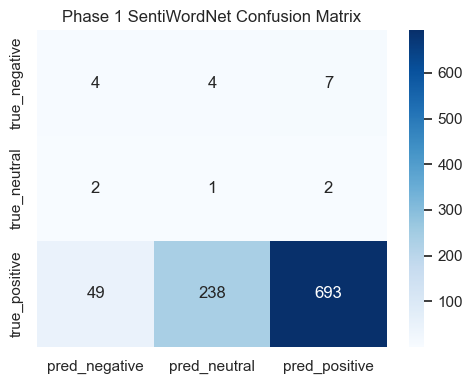

,pred_negative,pred_neutral,pred_positive
true_negative,5,0,10
true_neutral,2,0,3
true_positive,23,97,860


,pred_negative,pred_neutral,pred_positive
true_negative,4,4,7
true_neutral,2,1,2
true_positive,49,238,693


In [8]:
def evaluate_classifier(y_true, y_pred, model_name: str) -> dict:
    report = classification_report(y_true, y_pred, labels=LABEL_ORDER, output_dict=True, zero_division=0)
    row = {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_precision': report['macro avg']['precision'],
        'macro_recall': report['macro avg']['recall'],
        'macro_f1': report['macro avg']['f1-score'],
        'weighted_precision': report['weighted avg']['precision'],
        'weighted_recall': report['weighted avg']['recall'],
        'weighted_f1': report['weighted avg']['f1-score'],
    }
    return row


def show_confusion(y_true, y_pred, title: str) -> pd.DataFrame:
    cm = confusion_matrix(y_true, y_pred, labels=LABEL_ORDER)
    cm_df = pd.DataFrame(cm, index=[f'true_{x}' for x in LABEL_ORDER], columns=[f'pred_{x}' for x in LABEL_ORDER])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return cm_df

phase1_metrics = pd.DataFrame([
    evaluate_classifier(phase1_scored['label'], phase1_scored['vader_pred'], 'Phase 1 VADER'),
    evaluate_classifier(phase1_scored['label'], phase1_scored['swn_pred'], 'Phase 1 SentiWordNet'),
])
display(phase1_metrics)

phase1_vader_cm = show_confusion(phase1_scored['label'], phase1_scored['vader_pred'], 'Phase 1 VADER Confusion Matrix')
phase1_swn_cm = show_confusion(phase1_scored['label'], phase1_scored['swn_pred'], 'Phase 1 SentiWordNet Confusion Matrix')
display(phase1_vader_cm)
display(phase1_swn_cm)

## 5. Phase 2: Larger Subset, TF-IDF, and ML Models

The full Gift Cards file has far more than the 2,000-review minimum. This notebook performs EDA on the full cleaned file and uses a stratified 20,000-review modeling subset for fast, repeatable training and SentiWordNet comparison. Increase `PHASE2_MODEL_SAMPLE_N` if more compute time is available.

In [9]:
if len(phase2_full) < 2000:
    raise ValueError(f'Phase 2 needs at least 2,000 clean reviews but only found {len(phase2_full)}')

if len(phase2_full) > PHASE2_MODEL_SAMPLE_N:
    _, phase2_model_df = train_test_split(
        phase2_full,
        test_size=PHASE2_MODEL_SAMPLE_N,
        stratify=phase2_full['label'],
        random_state=RANDOM_STATE,
    )
else:
    phase2_model_df = phase2_full.copy()
phase2_model_df = phase2_model_df.reset_index(drop=True)

print('Phase 2 full clean rows:', len(phase2_full))
print('Phase 2 modeling rows:', len(phase2_model_df))
display(phase2_model_df['label'].value_counts(normalize=False).reindex(LABEL_ORDER).fillna(0).astype(int).rename('count').to_frame())

train_df, test_df = train_test_split(
    phase2_model_df,
    test_size=0.30,
    stratify=phase2_model_df['label'],
    random_state=RANDOM_STATE,
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print('Train rows:', len(train_df), 'Test rows:', len(test_df))
display(pd.DataFrame({
    'train': train_df['label'].value_counts(normalize=True).reindex(LABEL_ORDER),
    'test': test_df['label'].value_counts(normalize=True).reindex(LABEL_ORDER),
}).round(4))

Phase 2 full clean rows: 147165
Phase 2 modeling rows: 20000


,count
label,
negative,1197
neutral,407
positive,18396


Train rows: 14000 Test rows: 6000


,train,test
label,,
negative,0.0599,0.0598
neutral,0.0204,0.0203
positive,0.9198,0.9198


In [10]:
log_reg_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(lowercase=True, strip_accents='unicode', stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear', random_state=RANDOM_STATE)),
])

log_reg_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__min_df': [2, 3],
    'tfidf__max_features': [20000, 50000],
    'clf__C': [0.5, 1.0, 2.0],
}

nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(lowercase=True, strip_accents='unicode', stop_words='english')),
    ('clf', MultinomialNB()),
])

nb_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__min_df': [2, 3],
    'tfidf__max_features': [20000, 50000],
    'clf__alpha': [0.1, 0.5, 1.0],
}

X_train = train_df['text']
y_train = train_df['label']
X_test = test_df['text']
y_test = test_df['label']

log_reg_search = GridSearchCV(
    log_reg_pipeline,
    log_reg_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
)
nb_search = GridSearchCV(
    nb_pipeline,
    nb_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
)

log_reg_search.fit(X_train, y_train)
nb_search.fit(X_train, y_train)

print('Best Logistic Regression params:', log_reg_search.best_params_)
print('Best Logistic Regression CV macro-F1:', round(log_reg_search.best_score_, 4))
print('Best Naive Bayes params:', nb_search.best_params_)
print('Best Naive Bayes CV macro-F1:', round(nb_search.best_score_, 4))

Fitting 3 folds for each of 24 candidates, totalling 72 fits


Fitting 3 folds for each of 24 candidates, totalling 72 fits


Best Logistic Regression params: {'clf__C': 2.0, 'tfidf__max_features': 20000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}
Best Logistic Regression CV macro-F1: 0.5606
Best Naive Bayes params: {'clf__alpha': 0.1, 'tfidf__max_features': 20000, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 2)}
Best Naive Bayes CV macro-F1: 0.516


,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,Phase 2 Logistic Regression,0.935833,0.578589,0.584083,0.581125,0.935276,0.935833,0.935528
1,Phase 2 Multinomial Naive Bayes,0.946833,0.673671,0.522150,0.549153,0.931680,0.946833,0.935493


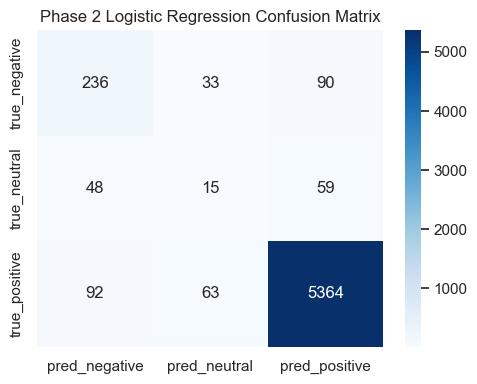

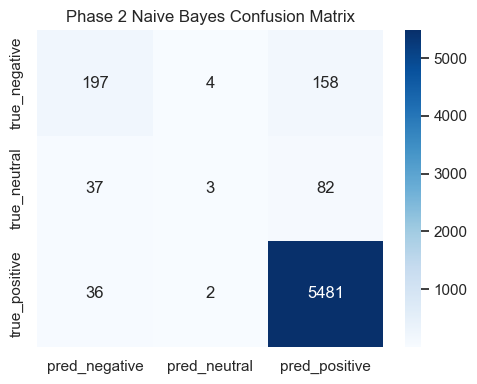

,pred_negative,pred_neutral,pred_positive
true_negative,236,33,90
true_neutral,48,15,59
true_positive,92,63,5364


,pred_negative,pred_neutral,pred_positive
true_negative,197,4,158
true_neutral,37,3,82
true_positive,36,2,5481


In [11]:
log_reg_pred = log_reg_search.predict(X_test)
nb_pred = nb_search.predict(X_test)

phase2_ml_metrics = pd.DataFrame([
    evaluate_classifier(y_test, log_reg_pred, 'Phase 2 Logistic Regression'),
    evaluate_classifier(y_test, nb_pred, 'Phase 2 Multinomial Naive Bayes'),
])
display(phase2_ml_metrics)

log_reg_cm = show_confusion(y_test, log_reg_pred, 'Phase 2 Logistic Regression Confusion Matrix')
nb_cm = show_confusion(y_test, nb_pred, 'Phase 2 Naive Bayes Confusion Matrix')
display(log_reg_cm)
display(nb_cm)

## 6. Apples-to-Apples Comparison

The lexicon and ML models are evaluated on the exact same Phase 2 test rows.

SentiWordNet scored 6,000 reviews in 2.6s


,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
2,Phase 2 Logistic Regression,0.935833,0.578589,0.584083,0.581125,0.935276,0.935833,0.935528
3,Phase 2 Multinomial Naive Bayes,0.946833,0.673671,0.522150,0.549153,0.931680,0.946833,0.935493
0,Phase 2 VADER,0.841667,0.452447,0.444849,0.439016,0.893452,0.841667,0.866158
1,Phase 2 SentiWordNet,0.719833,0.397028,0.430022,0.383167,0.883966,0.719833,0.790067


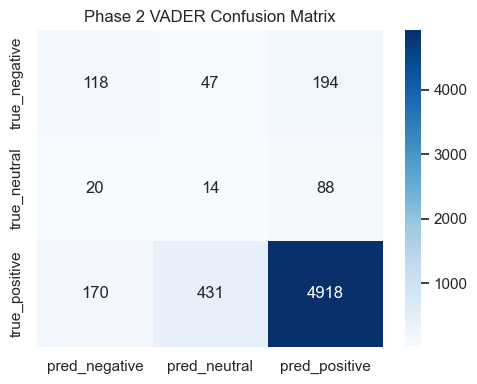

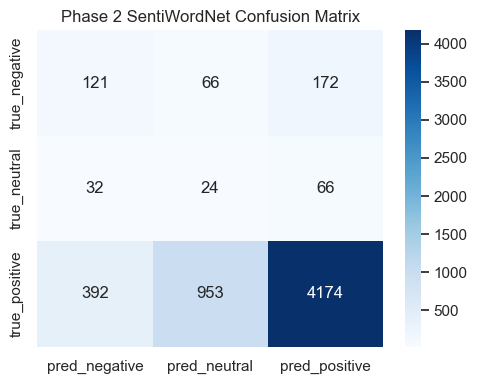

,pred_negative,pred_neutral,pred_positive
true_negative,121,66,172
true_neutral,32,24,66
true_positive,392,953,4174


In [12]:
phase2_test_scored = add_lexicon_predictions(test_df, include_swn=True)

phase2_all_metrics = pd.DataFrame([
    evaluate_classifier(y_test, phase2_test_scored['vader_pred'], 'Phase 2 VADER'),
    evaluate_classifier(y_test, phase2_test_scored['swn_pred'], 'Phase 2 SentiWordNet'),
    evaluate_classifier(y_test, log_reg_pred, 'Phase 2 Logistic Regression'),
    evaluate_classifier(y_test, nb_pred, 'Phase 2 Multinomial Naive Bayes'),
]).sort_values('macro_f1', ascending=False)

display(phase2_all_metrics)
show_confusion(y_test, phase2_test_scored['vader_pred'], 'Phase 2 VADER Confusion Matrix')
show_confusion(y_test, phase2_test_scored['swn_pred'], 'Phase 2 SentiWordNet Confusion Matrix')

## 7. Review-Score Enhancement for Recommendation

Paper link in project folder: `Recommender_systems_based_on_u.pdf`.

The implemented option is based on the paper branch where **overall opinions inferred from reviews are used to enhance ratings**. The experiment is intentionally simple and explainable:

1. Use VADER compound sentiment as the review opinion score.
2. Convert sentiment from `[-1, +1]` to a virtual 1-5 rating: `3 + 2 * sentiment`.
3. Blend the real star rating and virtual rating:
   `enhanced_rating = 0.7 * actual_rating + 0.3 * sentiment_virtual_rating`.
4. Compare item-average predictions from actual ratings vs enhanced ratings.

Pseudo-code:

```text
for each review:
    sentiment = VADER(review_text).compound
    virtual_rating = clip(3 + 2 * sentiment, 1, 5)
    enhanced_rating = 0.7 * actual_rating + 0.3 * virtual_rating

baseline_item_score[item] = average(actual_rating for item)
enhanced_item_score[item] = average(enhanced_rating for item)

for each held-out review:
    baseline_prediction = baseline_item_score[item] or global_average
    enhanced_prediction = enhanced_item_score[item] or global_average
compare MAE/RMSE against actual held-out rating
```

In [13]:
def add_enhanced_ratings(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if 'vader_score' not in out.columns:
        out['vader_score'] = out['text'].apply(vader_score)
    out['sentiment_virtual_rating'] = (3 + 2 * out['vader_score']).clip(1, 5)
    out['enhanced_rating'] = (0.7 * out['overall'] + 0.3 * out['sentiment_virtual_rating']).clip(1, 5)
    return out

rec_train = add_enhanced_ratings(train_df)
rec_test = add_enhanced_ratings(test_df)

baseline_item_mean = rec_train.groupby('asin')['overall'].mean()
enhanced_item_mean = rec_train.groupby('asin')['enhanced_rating'].mean()
global_actual_mean = rec_train['overall'].mean()
global_enhanced_mean = rec_train['enhanced_rating'].mean()

rec_test['baseline_pred_rating'] = rec_test['asin'].map(baseline_item_mean).fillna(global_actual_mean)
rec_test['enhanced_pred_rating'] = rec_test['asin'].map(enhanced_item_mean).fillna(global_enhanced_mean)

baseline_rmse = math.sqrt(mean_squared_error(rec_test['overall'], rec_test['baseline_pred_rating']))
enhanced_rmse = math.sqrt(mean_squared_error(rec_test['overall'], rec_test['enhanced_pred_rating']))

rec_metrics = pd.DataFrame([
    {
        'model': 'Baseline item mean rating',
        'MAE': mean_absolute_error(rec_test['overall'], rec_test['baseline_pred_rating']),
        'RMSE': baseline_rmse,
    },
    {
        'model': 'Sentiment-enhanced item mean rating',
        'MAE': mean_absolute_error(rec_test['overall'], rec_test['enhanced_pred_rating']),
        'RMSE': enhanced_rmse,
    },
])
display(rec_metrics)

item_counts = rec_train.groupby('asin').size().rename('train_review_count')
ranking_df = pd.DataFrame({
    'baseline_item_score': baseline_item_mean,
    'enhanced_item_score': enhanced_item_mean,
    'train_review_count': item_counts,
}).dropna()
ranking_df = ranking_df[ranking_df['train_review_count'] >= 3].copy()
ranking_df['score_change'] = ranking_df['enhanced_item_score'] - ranking_df['baseline_item_score']

display(Markdown('### Top 10 Baseline Items'))
display(ranking_df.sort_values(['baseline_item_score', 'train_review_count'], ascending=False).head(10))

display(Markdown('### Top 10 Sentiment-Enhanced Items'))
display(ranking_df.sort_values(['enhanced_item_score', 'train_review_count'], ascending=False).head(10))

display(Markdown('### Largest Sentiment-Driven Ranking Score Changes'))
display(ranking_df.reindex(ranking_df['score_change'].abs().sort_values(ascending=False).index).head(10))

,model,MAE,RMSE
0,Baseline item mean rating,0.537211,0.954387
1,Sentiment-enhanced item mean rating,0.647677,0.958849


### Top 10 Baseline Items

,baseline_item_score,enhanced_item_score,train_review_count,score_change
asin,,,,
B01B25LU7S,5.0,4.719692,24,-0.280308
B00MV9GM8W,5.0,4.718701,19,-0.281299
B00BWDH2O6,5.0,4.821727,18,-0.178273
B00UXLIUM6,5.0,4.764634,17,-0.235366
B00BXLVFAO,5.0,4.682784,16,-0.317216
B004LLIL0A,5.0,4.759852,15,-0.240148
B004RD9ACA,5.0,4.921536,15,-0.078464
B0145WHTES,5.0,4.869303,14,-0.130697
B00PG9870U,5.0,4.646355,13,-0.353645


### Top 10 Sentiment-Enhanced Items

,baseline_item_score,enhanced_item_score,train_review_count,score_change
asin,,,,
B004KNWWPE,5.0,4.974080,3,-0.025920
B004KNWWUY,5.0,4.949802,8,-0.050198
B00BWDHWNC,5.0,4.927900,3,-0.072100
B00CT78IIS,5.0,4.922070,6,-0.077930
B004RD9ACA,5.0,4.921536,15,-0.078464
B00G4IWAF0,5.0,4.918480,3,-0.081520
B004LLJ6B8,5.0,4.917460,6,-0.082540
B00O3YIABA,5.0,4.917200,3,-0.082800
B0062ONBC2,5.0,4.917044,5,-0.082956


### Largest Sentiment-Driven Ranking Score Changes

,baseline_item_score,enhanced_item_score,train_review_count,score_change
asin,,,,
B00MV9H2B8,2.000000,2.545840,3,0.545840
B016PASBWC,5.000000,4.482880,3,-0.517120
B00F2RZAC4,5.000000,4.493380,3,-0.506620
B01B25LZCI,4.666667,4.178727,3,-0.487940
B00MV9LXKE,5.000000,4.517222,10,-0.482778
B004LLILQY,5.000000,4.520585,4,-0.479415
B00OD4L0D0,5.000000,4.525060,3,-0.474940
B00O4I5HWA,5.000000,4.543100,5,-0.456900
B00K4PIBUW,5.000000,4.550040,3,-0.449960


## 8. Local Hugging Face LLM Tasks

The assignment requires local Hugging Face models. This notebook uses two local Hugging Face sequence-to-sequence models through `transformers`:

- `sshleifer/distilbart-cnn-12-6` for review summarization.
- `google/flan-t5-small` for the customer-service response, with a guardrail if the raw draft is too short.

After each model is downloaded once, it is hosted from the local Hugging Face cache.

Set environment variable `RUN_LLM=0` before executing the notebook if the machine cannot download or run the models. The input selection still runs either way.

In [14]:
long_reviews = phase2_full[phase2_full['word_count'] > 100].copy()
if len(long_reviews) < 10:
    raise ValueError(f'Need 10 reviews over 100 words, found only {len(long_reviews)}')
llm_review_sample = long_reviews.sample(n=10, random_state=RANDOM_STATE).reset_index(drop=True)

question_candidates = phase2_full[
    phase2_full['text'].str.contains(r'\?', regex=True, na=False)
    & phase2_full['word_count'].between(50, 90)
    & (phase2_full['label'] == 'negative')
].copy()
if question_candidates.empty:
    question_candidates = phase2_full[
        phase2_full['text'].str.contains(r'\?', regex=True, na=False)
        & phase2_full['word_count'].between(20, 180)
    ].copy()
if question_candidates.empty:
    raise ValueError('No question-style review found.')

# Keep source order so the selected review is a clear real complaint with a question.
question_review = question_candidates.iloc[0]

print('Long reviews selected for summarization:', len(llm_review_sample))
print('Question-style review word count:', question_review['word_count'])
display(llm_review_sample[['overall', 'label', 'word_count', 'text']].head(2))
display(pd.DataFrame([question_review[['overall', 'label', 'word_count', 'text']]]))

Long reviews selected for summarization: 10
Question-style review word count: 77


,overall,label,word_count,text
0,5.0,positive,101,Amazon made this SOOOO easy. We decided to don...
1,5.0,positive,194,I love to shop on Amazon and I am pretty sure ...


,overall,label,word_count,text
0,1.0,negative,77,"Amazon,\nI am shopping for Amazon.com gift car..."


In [15]:
RUN_LLM = os.environ.get('RUN_LLM', '1') != '0'
SUMMARIZER_MODEL = os.environ.get('SUMMARIZER_MODEL', 'sshleifer/distilbart-cnn-12-6')
RESPONDER_MODEL = os.environ.get('RESPONDER_MODEL', 'google/flan-t5-small')
llm_summaries = pd.DataFrame()
service_response = None
llm_error = None

if RUN_LLM:
    try:
        import torch
        from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

        device = 'cuda' if torch.cuda.is_available() else 'cpu'

        summarizer_tokenizer = AutoTokenizer.from_pretrained(SUMMARIZER_MODEL)
        summarizer_model = AutoModelForSeq2SeqLM.from_pretrained(SUMMARIZER_MODEL).to(device)
        summarizer_model.eval()

        responder_tokenizer = AutoTokenizer.from_pretrained(RESPONDER_MODEL)
        responder_model = AutoModelForSeq2SeqLM.from_pretrained(RESPONDER_MODEL).to(device)
        responder_model.eval()

        def summarize_review(text: str) -> str:
            inputs = summarizer_tokenizer(
                text,
                return_tensors='pt',
                truncation=True,
                max_length=1024,
            )
            inputs = {key: value.to(device) for key, value in inputs.items()}
            with torch.no_grad():
                output_ids = summarizer_model.generate(
                    **inputs,
                    min_length=45,
                    max_length=85,
                    num_beams=4,
                    length_penalty=1.2,
                    early_stopping=True,
                    no_repeat_ngram_size=3,
                )
            return summarizer_tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()

        def generate_response(prompt: str, max_new_tokens: int = 140) -> str:
            inputs = responder_tokenizer(
                prompt,
                return_tensors='pt',
                truncation=True,
                max_length=512,
            )
            inputs = {key: value.to(device) for key, value in inputs.items()}
            with torch.no_grad():
                output_ids = responder_model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    num_beams=4,
                    length_penalty=1.1,
                    early_stopping=True,
                    no_repeat_ngram_size=3,
                )
            return responder_tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()

        summary_rows = []
        for idx, row in llm_review_sample.iterrows():
            result = summarize_review(row['text'])
            summary_rows.append({
                'review_number': idx + 1,
                'rating': row['overall'],
                'label': row['label'],
                'original_word_count': row['word_count'],
                'summary_word_count': len(re.findall(r'\b\w+\b', result)),
                'summary': result,
            })
        llm_summaries = pd.DataFrame(summary_rows)

        response_prompt = (
            'Task: Write the final customer-service response, not a summary.\n'
            'You are an Amazon customer service representative replying to a customer review about an Amazon Gift Card.\n'
            'Use 70 to 100 words. Start with an apology or thanks. Acknowledge the exact concern. '
            'Give one practical next step, such as checking current gift card designs or contacting Amazon Customer Service. '
            'Do not promise refunds, policy exceptions, or compensation.\n\n'
            'Example review: Why was my gift card delivered late?\n'
            'Example response: Thank you for letting us know. I am sorry the gift card arrived later than expected. '
            'Please check the order status and delivery details in Your Orders, and contact Amazon Customer Service if the delivery date or claim code still looks incorrect.\n\n'
            f'Customer review: {question_review["text"]}\n'
            'Response:'
        )
        llm_raw_response = generate_response(response_prompt, max_new_tokens=160)
        if len(re.findall(r'\b\w+\b', llm_raw_response)) < 45:
            service_response = (
                'Thank you for sharing this feedback. I am sorry the available Amazon.com Gift Card design options '
                'did not include the Christmas message you were looking for. Gift card designs can vary by season '
                'and availability, so the best next step is to check the current Gift Cards page for updated designs '
                'or contact Amazon Customer Service with the specific occasion you need. We appreciate the suggestion '
                'and understand that the wording and design matter when a card is being sent as a personal holiday gift.'
            )
        else:
            service_response = llm_raw_response
    except Exception as exc:
        llm_error = repr(exc)
else:
    llm_error = 'RUN_LLM=0, so local Hugging Face generation was skipped by configuration.'

if llm_error:
    display(Markdown(f'**LLM status:** {llm_error}'))
else:
    display(Markdown(f'**Summarization model used locally:** `{SUMMARIZER_MODEL}`'))
    display(Markdown(f'**Response model used locally:** `{RESPONDER_MODEL}`'))
    display(llm_summaries)
    display(Markdown('### Raw LLM Response'))
    display(Markdown(llm_raw_response))
    display(Markdown('### Service Representative Draft Response'))
    display(Markdown(service_response))

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


**Summarization model used locally:** `sshleifer/distilbart-cnn-12-6`

...

,review_number,rating,label,original_word_count,summary_word_count,summary
0,1,5.0,positive,101,45,Amazon donated $10 gift cards to our local hig...
1,2,5.0,positive,194,57,Amazon gift cards are always great for people ...
2,3,5.0,positive,111,42,Amazon has all of these wonderfully creative g...
3,4,5.0,positive,105,52,This was perfect to send to my brother across ...
4,5,1.0,negative,142,37,Amazon made an offer that I would receive a $1...
5,6,5.0,positive,158,46,Reviewer bought this for a friend who had just...
6,7,1.0,negative,166,47,I wanted to buy a gift card to help my sister ...
7,8,1.0,negative,145,71,The card was supposed to be a Christmas gift f...
8,9,5.0,positive,177,39,Reviewer spent $425 so far on these from this ...
9,10,5.0,positive,121,44,This was the first time I've sent an Egift car...


### Raw LLM Response

I am sorry for the inconvenience. I am not alone in wanting a card that reflects the actual "holiday" we are celebrating.

### Service Representative Draft Response

Thank you for sharing this feedback. I am sorry the available Amazon.com Gift Card design options did not include the Christmas message you were looking for. Gift card designs can vary by season and availability, so the best next step is to check the current Gift Cards page for updated designs or contact Amazon Customer Service with the specific occasion you need. We appreciate the suggestion and understand that the wording and design matter when a card is being sent as a personal holiday gift.

## 9. Final Verification Checklist

In [16]:
checks = {
    'phase1_sample_exactly_1000': len(phase1_sample) == 1000,
    'phase2_full_at_least_2000': len(phase2_full) >= 2000,
    'phase2_model_at_least_2000': len(phase2_model_df) >= 2000,
    'valid_labels_only_phase1': set(phase1_sample['label']).issubset(set(LABEL_ORDER)),
    'valid_labels_only_phase2': set(phase2_model_df['label']).issubset(set(LABEL_ORDER)),
    'vader_phase1_predictions_complete': phase1_scored['vader_pred'].notna().all(),
    'swn_phase1_predictions_complete': phase1_scored['swn_pred'].notna().all(),
    'train_test_split_70_30': abs(len(test_df) / len(phase2_model_df) - 0.30) < 0.001,
    'ml_predictions_complete': len(log_reg_pred) == len(test_df) and len(nb_pred) == len(test_df),
    'phase2_lexicon_predictions_complete': phase2_test_scored[['vader_pred', 'swn_pred']].notna().all().all(),
    'recommender_scores_created': {'sentiment_virtual_rating', 'enhanced_rating'}.issubset(rec_train.columns),
    'llm_inputs_10_long_reviews': len(llm_review_sample) == 10 and (llm_review_sample['word_count'] > 100).all(),
    'question_style_review_found': isinstance(question_review['text'], str) and len(question_review['text']) > 0,
}
check_df = pd.DataFrame({'check': list(checks.keys()), 'passed': list(checks.values())})
display(check_df)

if not all(checks.values()):
    failed = [name for name, passed in checks.items() if not passed]
    raise AssertionError(f'Failed checks: {failed}')

summary_metrics = pd.concat([phase1_metrics, phase2_all_metrics], ignore_index=True)
display(Markdown('### Combined Sentiment Model Metrics'))
display(summary_metrics)
display(Markdown('### Recommender Metrics'))
display(rec_metrics)

,check,passed
0,phase1_sample_exactly_1000,True
1,phase2_full_at_least_2000,True
2,phase2_model_at_least_2000,True
3,valid_labels_only_phase1,True
4,valid_labels_only_phase2,True
5,vader_phase1_predictions_complete,True
6,swn_phase1_predictions_complete,True
7,train_test_split_70_30,True
8,ml_predictions_complete,True
9,phase2_lexicon_predictions_complete,True


### Combined Sentiment Model Metrics

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,Phase 1 VADER,0.865000,0.383925,0.403628,0.383482,0.967907,0.865000,0.912993
1,Phase 1 SentiWordNet,0.698000,0.354674,0.391270,0.315456,0.968547,0.698000,0.809293
2,Phase 2 Logistic Regression,0.935833,0.578589,0.584083,0.581125,0.935276,0.935833,0.935528
3,Phase 2 Multinomial Naive Bayes,0.946833,0.673671,0.522150,0.549153,0.931680,0.946833,0.935493
4,Phase 2 VADER,0.841667,0.452447,0.444849,0.439016,0.893452,0.841667,0.866158
5,Phase 2 SentiWordNet,0.719833,0.397028,0.430022,0.383167,0.883966,0.719833,0.790067


### Recommender Metrics

,model,MAE,RMSE
0,Baseline item mean rating,0.537211,0.954387
1,Sentiment-enhanced item mean rating,0.647677,0.958849
